In [1]:
# Import modules
import numpy as np
from pathlib import Path
import os
from os import chdir
import xgcm
import gsw
import pandas as pd
from scipy.stats import linregress
import re
from datetime import datetime
import glob

# Maps and figures
from matplotlib.ticker import MultipleLocator, FuncFormatter
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import cmocean

In [2]:
ECCO_version = 'v4r4'
#ECCO_version = 'v4r5'

In [3]:
df = pd.read_csv(f'N2_D_COM_partial_mean_ECCO{ECCO_version}.csv',index_col=None,parse_dates=["time"])

In [4]:
df = df.set_index(['time','depth'])

In [5]:
list_depth = df.index.get_level_values("depth").unique().to_numpy()
list_times = df.index.get_level_values("time").unique().tolist()

In [6]:
import numpy as np
import pandas as pd
from scipy.stats import kendalltau

# df: rows indexed by MultiIndex ('time','depth'); columns are numeric variables

SECS_PER_YEAR = 365.25 * 24 * 3600.0

def _kendalltau_pvalue(t, y):
    res = kendalltau(t, y)
    return res.pvalue

def _regress_tc(t, y):
    """
    OLS for y ~ m*t + b with per-column NaN handling.
    Returns: slope, intercept, stderr_fit, stderr_slope
      - stderr_fit: residual std error = sqrt(SSE/(n-2))
      - stderr_slope: std error of slope from covariance matrix
    """
    mask = ~np.isnan(y)
    n = mask.sum()
    if n < 3:
        return np.nan, np.nan, np.nan, np.nan

    tc = t[mask]
    yc = y[mask]

    # Design matrix [t, 1]
    X = np.c_[tc, np.ones_like(tc)]
    # Solve least squares
    beta, *_ = np.linalg.lstsq(X, yc, rcond=None)
    slope, intercept = beta

    # Residuals and residual variance
    yhat = X @ beta
    resid = yc - yhat
    sse = float((resid**2).sum())
    dof = n - 2
    if dof <= 0:
        return slope, intercept, np.nan, np.nan
    sigma2 = sse / dof

    # (X'X)^(-1) for standard errors
    XtX = X.T @ X
    try:
        XtX_inv = np.linalg.inv(XtX)
    except np.linalg.LinAlgError:
        # perfectly collinear t (e.g., all identical times)
        return np.nan, np.nan, np.nan, np.nan

    var_slope = sigma2 * XtX_inv[0, 0]
    stderr_fit = np.sqrt(sigma2)
    stderr_slope = np.sqrt(var_slope) if var_slope >= 0 else np.nan

    return slope, intercept, stderr_fit, stderr_slope


def _compute_stats(df_in: pd.DataFrame, timescale: str) -> pd.DataFrame:
    assert isinstance(df_in.index, pd.MultiIndex)
    time = df_in.index.get_level_values("time")
    t_sec = time.view("i8") / 1e9
    t_sec_mean = np.nanmean(t_sec)  # keep global center

    rows = []
    for depth_val, g in df_in.groupby(level="depth", sort=True):
        # >>> FIX: build t from the group’s own time level (not idx.codes)
        t_g = g.index.get_level_values("time").view("i8") / 1e9
        t_g = t_g - t_sec_mean
        means = g.mean(axis=0, skipna=True)
        stds = g.std(axis=0, skipna=True)

        for col in g.columns:
            y = g[col].to_numpy()
            slope_sec, intercept, stderr_fit, stderr_slope_sec = _regress_tc(t_g, y)
            slope_year = slope_sec * SECS_PER_YEAR if np.isfinite(slope_sec) else np.nan
            stderr_slope_year = stderr_slope_sec * SECS_PER_YEAR if np.isfinite(stderr_slope_sec) else np.nan
            time_mean = float(means[col]) if pd.notna(means[col]) else np.nan
            time_std = float(stds[col]) if pd.notna(stds[col]) else np.nan
            rel_change = (slope_year / time_mean * 100.0) if (np.isfinite(slope_year) and pd.notna(time_mean) and time_mean != 0) else np.nan
            rel_stderr = (stderr_fit / time_mean * 100.0) if (np.isfinite(stderr_fit) and pd.notna(time_mean) and time_mean != 0) else np.nan
            rel_stderr_slope = (stderr_slope_year / time_mean * 100.0) if (np.isfinite(stderr_slope_year) and pd.notna(time_mean) and time_mean != 0) else np.nan
            kendalltau_pvalue = _kendalltau_pvalue(t_g, y)

            rows.append({
                "timescale": timescale,
                "depth": depth_val,
                "variable": col,
                "time_mean": time_mean,
                "time_std": time_std,
                "slope_per_year": slope_year,
                "stderr_linear_fit": stderr_fit,
                "stderr_slope_per_year": stderr_slope_year,
                "rel_change": rel_change,
                "rel_stderr": rel_stderr,
                "rel_stderr_slope_per_year": rel_stderr_slope,
                "kendalltau_pvalue": kendalltau_pvalue
            })
    return pd.DataFrame(rows)

def stats_per_depth(df: pd.DataFrame) -> pd.DataFrame:
    # monthly stats
    monthly = _compute_stats(df, timescale="monthly")

    # annual-mean series (Jan–Dec); change freq='A' to 'AS-JUL' etc. if needed
    df_year = df.groupby([pd.Grouper(level="time", freq="YE"), "depth"]).mean()
    annual = _compute_stats(df_year, timescale="annual")

    out = pd.concat([monthly, annual], ignore_index=True)
    return out.set_index(["timescale", "depth", "variable"]).sort_index()


In [7]:
trends_df = stats_per_depth(df)
trends_monthly_df = trends_df.xs('monthly',level=0)
trends_annual_df  = trends_df.xs('annual',level=0)

In [8]:
plot_df = pd.DataFrame(index=list_depth)

In [9]:
n2_cols = trends_monthly_df.xs('N2_mean',level=1)
com_cols = trends_monthly_df.xs('CoM',level=1)

In [10]:
plot_df['N2_mean'] = n2_cols["time_mean"].values
plot_df['CoM_mean'] = com_cols["time_mean"].values

plot_df['N2_std'] = n2_cols["time_std"].values
plot_df['CoM_std'] = com_cols["time_std"].values

plot_df['N2_trend'] = n2_cols['slope_per_year'].values
plot_df['CoM_trend'] = com_cols['slope_per_year'].values

plot_df['N2_SE'] = n2_cols["stderr_slope_per_year"].values
plot_df['CoM_SE'] = com_cols["stderr_slope_per_year"].values

plot_df['N2_RC'] = n2_cols["rel_change"].values
plot_df['CoM_RC'] = com_cols["rel_change"].values

plot_df['N2_RC_SE'] = n2_cols["rel_stderr_slope_per_year"].values
plot_df['CoM_RC_SE'] = com_cols["rel_stderr_slope_per_year"].values

plot_df['N2_tau_pvalue'] = n2_cols["kendalltau_pvalue"].values
plot_df['CoM_tau_pvalue'] = com_cols["kendalltau_pvalue"].values

In [11]:
rows = [207, 513, 1056, 1993, 6134]
summary = pd.DataFrame(index=rows)

for metric in ["N2", "CoM"]:
    mean_vals = plot_df.loc[rows, f"{metric}_mean"]
    trend_vals = plot_df.loc[rows, f"{metric}_trend"]
    rel_trend = plot_df.loc[rows, f"{metric}_RC"]
    se_vals = plot_df.loc[rows, f"{metric}_RC_SE"]

    if metric == "N2":
        summary[(metric, "mean [s⁻²]")] = mean_vals
        summary[(metric, "trend [s⁻² yr⁻¹]")] = trend_vals
        summary[(metric, "rel_trend [% yr⁻¹]")] = rel_trend
        summary[(metric, "SE [% yr⁻¹]")] = se_vals

    elif metric == "CoM":
        summary[(metric, "mean [m]")] = mean_vals
        summary[(metric, "trend [m yr⁻¹]")] = trend_vals
        summary[(metric, "rel_trend [% yr⁻¹]")] = rel_trend
        summary[(metric, "SE [% yr⁻¹]")] = se_vals

summary.columns = pd.MultiIndex.from_tuples(summary.columns, names=["Metric", "Value"])
summary

Metric         N2                                                       CoM  \
Value  mean [s⁻²] trend [s⁻² yr⁻¹] rel_trend [% yr⁻¹] SE [% yr⁻¹]  mean [m]   
207      0.000008     7.258338e-09           0.087012    0.009477  0.688619   
513      0.000008     7.251375e-09           0.086926    0.009473  0.688666   
1056     0.000008     7.264755e-09           0.087086    0.009474  0.688678   
1993     0.000008     7.296008e-09           0.087461    0.009475  0.688680   
6134     0.000008     7.499465e-09           0.089900    0.009476  0.688679   

Metric                                                
Value  trend [m yr⁻¹] rel_trend [% yr⁻¹] SE [% yr⁻¹]  
207          0.000341           0.049561    0.001885  
513          0.000513           0.074499    0.001820  
1056         0.000568           0.082425    0.001837  
1993         0.000603           0.087500    0.001827  
6134         0.000658           0.095500    0.001825

In [12]:
plot_df = pd.merge(plot_df.reset_index(names='depth'),pd.read_csv(f'volumes_per_depth_ECCO{ECCO_version}.csv',index_col=None)).set_index('depth')

In [13]:
plot_df['CoM_trend_per_depth'] = np.gradient(plot_df.CoM_trend.values, plot_df.index.values)
plot_df['N2_trend_per_depth'] = np.gradient(plot_df.N2_trend.values, plot_df.index.values)
plot_df['CoM_RC_per_depth'] = np.gradient(plot_df.CoM_RC.values, plot_df.index.values)
plot_df['N2_RC_per_depth'] = np.gradient(plot_df.N2_RC.values, plot_df.index.values)

In [14]:
depth = plot_df.index.to_numpy()
y = plot_df['CoM_trend_per_depth'].where(depth<1500).to_numpy()

In [15]:
B, lnA = np.polyfit(depth[np.isfinite(y)], np.log(y[np.isfinite(y)]), 1)
print('depth scale = ',-1/B)
A = np.exp(lnA)
plot_df['CoM_trend_per_depth_expfit'] = A * np.exp(B * depth)

depth scale =  320.0048582504386


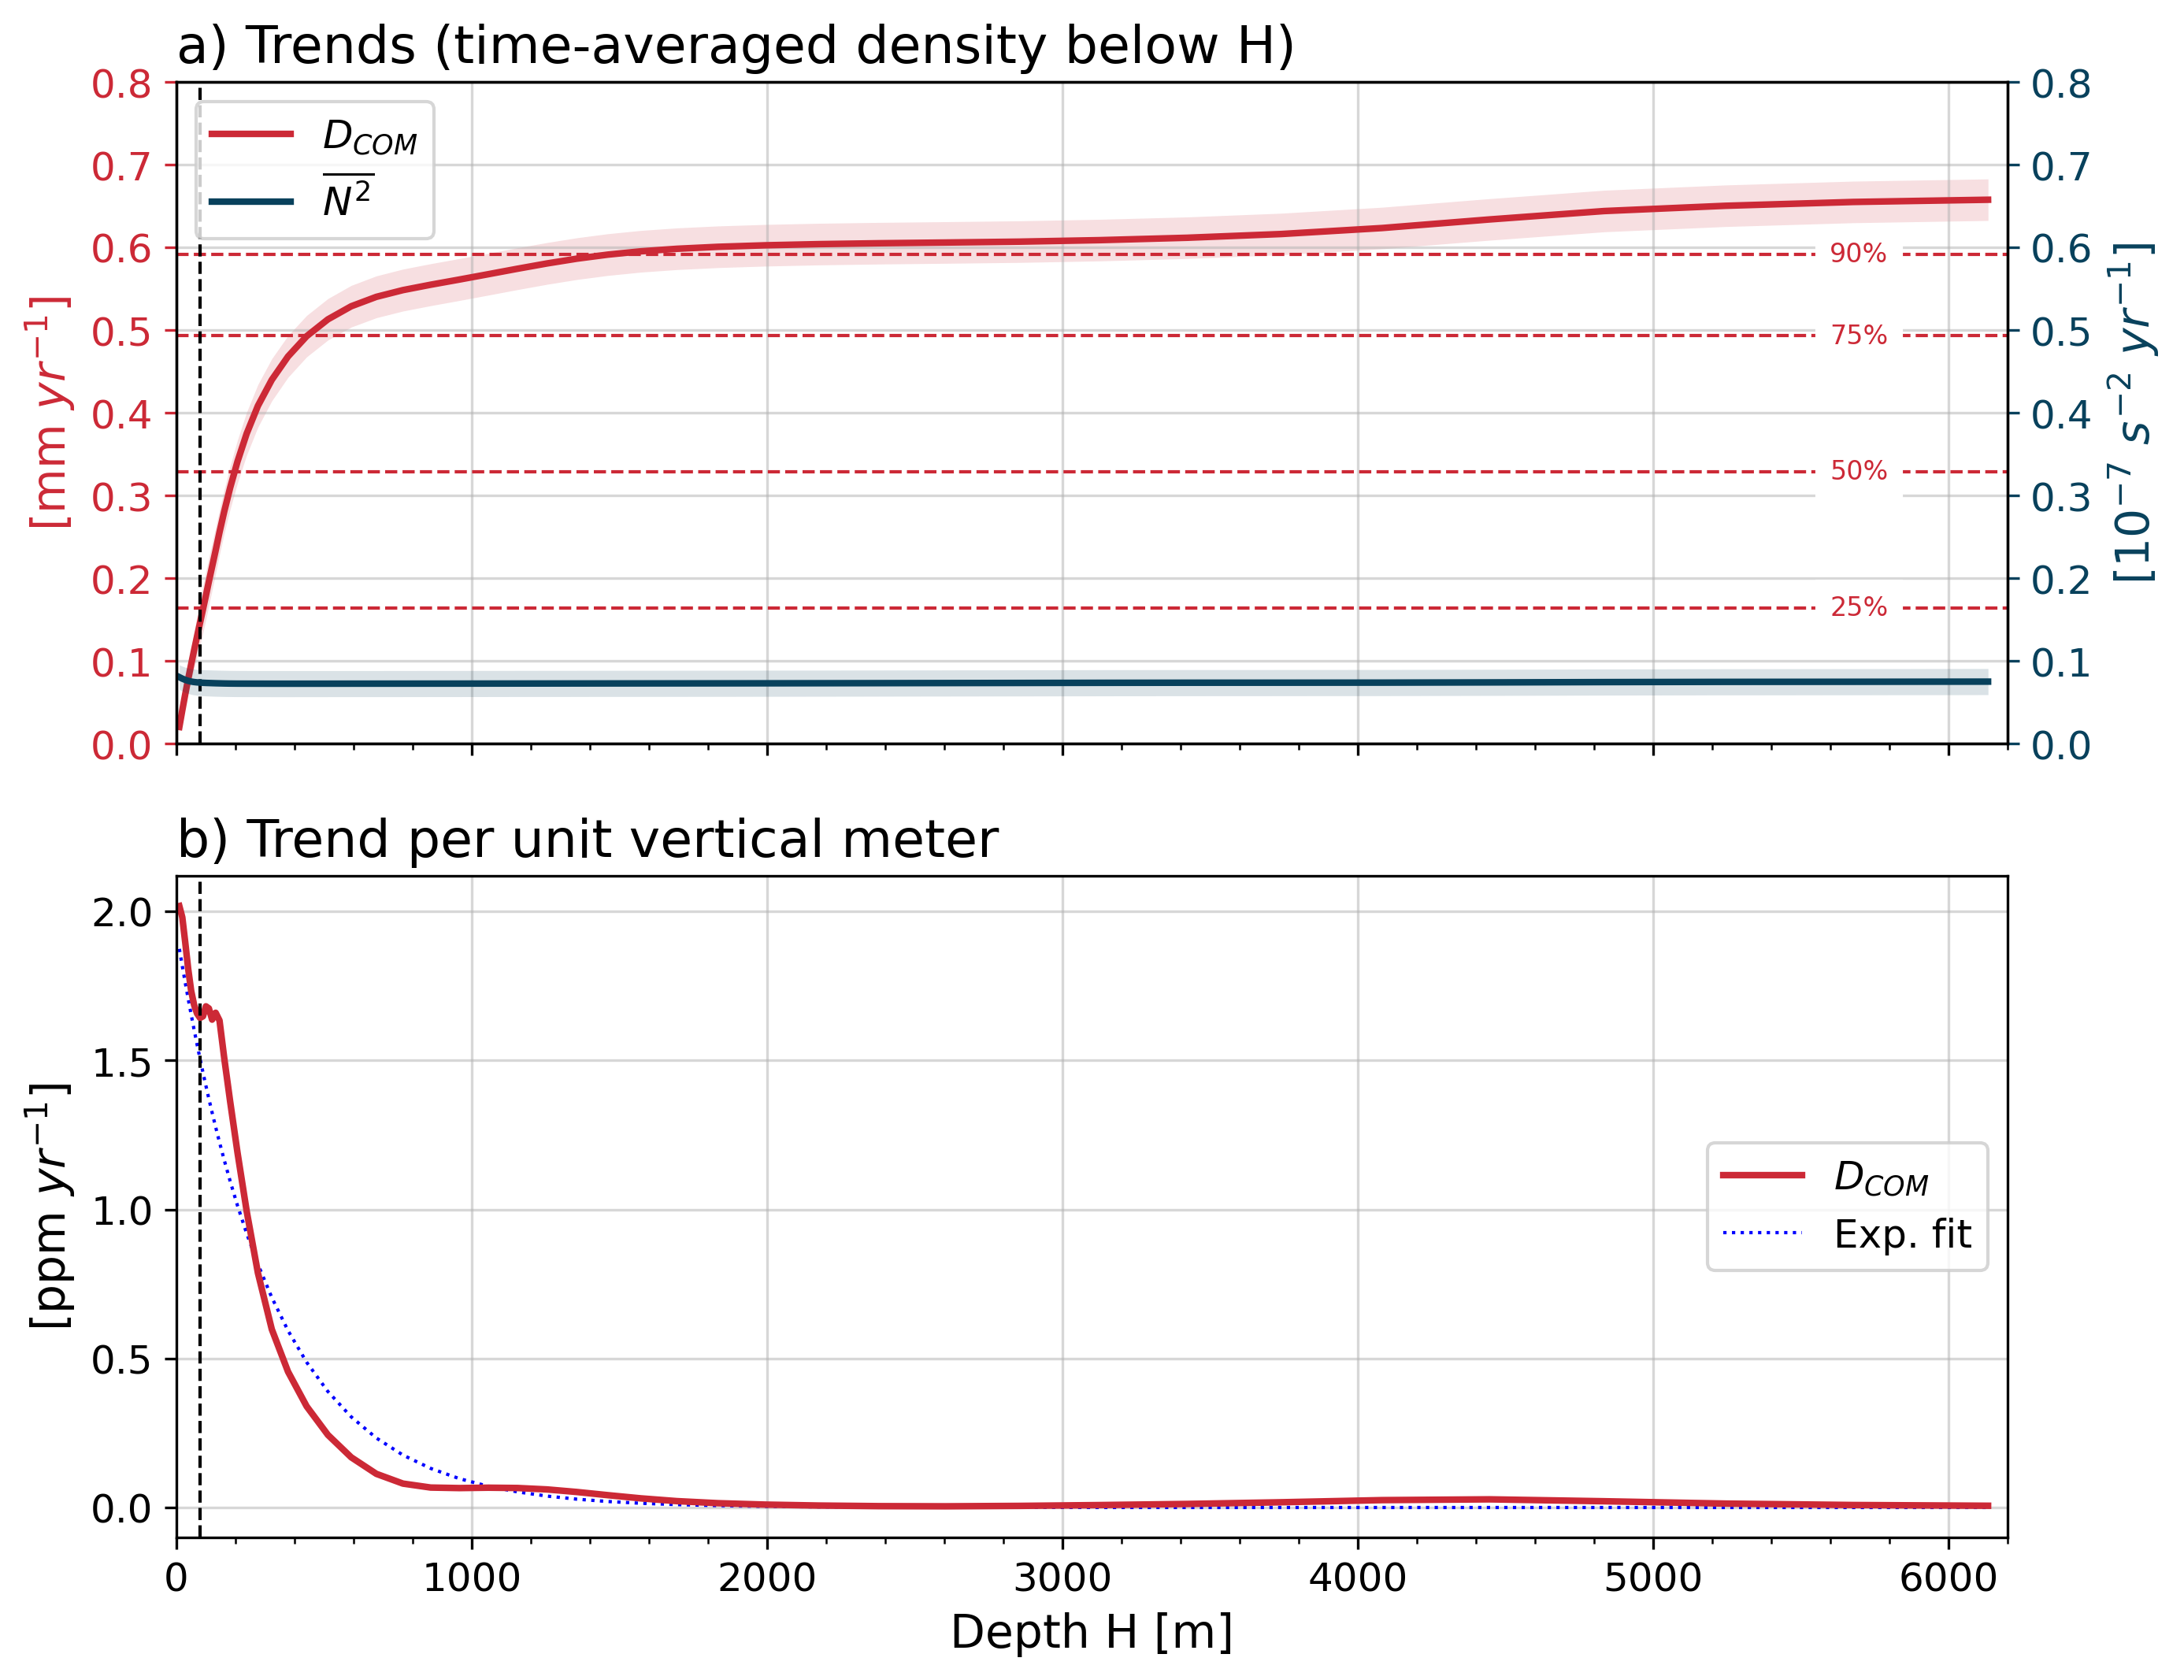

In [16]:
plt.rcParams.update({
    "font.size": 12,
    "font.family": "sans-serif",
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

fig, axes = plt.subplots(2, 1, figsize=(10, 8), dpi=300, sharex=True)

# -------------------
# 1st subplot
ax1 = axes[0]
ax2 = ax1.twinx()

line1, = ax1.plot(plot_df.index, plot_df.CoM_trend*1e3, color='#CC2936', linewidth=2, label=r'$D_{COM}$')
line3, = ax2.plot(plot_df.index, plot_df.N2_trend*1e7, color='#08415C', linewidth=2, label=r'$\overline{N^2}$')
ax1.fill_between(plot_df.index, (plot_df.CoM_trend - plot_df.CoM_SE*2)*1e3, (plot_df.CoM_trend + plot_df.CoM_SE*2)*1e3, alpha=0.15, color= '#CC2936', linewidth=0)
ax2.fill_between(plot_df.index, (plot_df.N2_trend - plot_df.N2_SE*2)*1e7, (plot_df.N2_trend + plot_df.N2_SE*2)*1e7, alpha=0.15, color='#08415C', linewidth=0)

y = plot_df.CoM_trend.iloc[-1]*1e3 / 2
ax1.axhline(y, color='#CC2936', linestyle='--', linewidth=1)
ax1.text(
    ax1.get_xlim()[1]*0.9,  # x-position: far right of current x-axis
    y,                  # y-position: same as line
    '50%',              # text label
    va='center',        # vertical alignment
    ha='right',         # horizontal alignment (stick to right edge)
    color='#CC2936',    # match line color
    fontsize=8,         # small font
    backgroundcolor='white',  # optional: improve readability
)

y = plot_df.CoM_trend.iloc[-1]*1e3 *0.25
ax1.axhline(y, color='#CC2936', linestyle='--', linewidth=1)
ax1.text(
    ax1.get_xlim()[1]*0.9,  # x-position: far right of current x-axis
    y,                  # y-position: same as line
    '25%',              # text label
    va='center',        # vertical alignment
    ha='right',         # horizontal alignment (stick to right edge)
    color='#CC2936',    # match line color
    fontsize=8,         # small font
    backgroundcolor='white',  # optional: improve readability
)

y = plot_df.CoM_trend.iloc[-1]*1e3 *0.75
ax1.axhline(y, color='#CC2936', linestyle='--', linewidth=1)
ax1.text(
    ax1.get_xlim()[1]*0.9,  # x-position: far right of current x-axis
    y,                  # y-position: same as line
    '75%',              # text label
    va='center',        # vertical alignment
    ha='right',         # horizontal alignment (stick to right edge)
    color='#CC2936',    # match line color
    fontsize=8,         # small font
    backgroundcolor='white',  # optional: improve readability
)

y = plot_df.CoM_trend.iloc[-1]*1e3 *0.9
ax1.axhline(y, color='#CC2936', linestyle='--', linewidth=1)
ax1.text(
    ax1.get_xlim()[1]*0.9,  # x-position: far right of current x-axis
    y,                  # y-position: same as line
    '90%',              # text label
    va='center',        # vertical alignment
    ha='right',         # horizontal alignment (stick to right edge)
    color='#CC2936',    # match line color
    fontsize=8,         # small font
    backgroundcolor='white',  # optional: improve readability
)

ax1.set_ylabel("[mm " r"$yr^{-1}$]", color='#CC2936')
ax2.set_ylabel(r"[$10^{-7}$" " " r"$s^{-2}$" " " r"$yr^{-1}$]", color='#08415C')
ax1.set_title('a) Trends (time-averaged density below H)', loc='left', fontsize=16)

ax1.tick_params(axis='y', color='#CC2936', labelcolor='#CC2936')
ax2.tick_params(axis='y', color='#08415C', labelcolor='#08415C')

lines = [line1, line3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left", frameon=True, fancybox=True, framealpha=0.8)
ax1.grid(linestyle='-', alpha=0.5)

ax1.axvline(78.94319, color='k', linestyle='--', linewidth=1)

ax1.set_ylim(0,.8)
ax2.set_ylim(0,.8)
ax2.set_yticks(ax1.get_yticks())

# -------------------
# 2nd subplot
ax1 = axes[1]

line2, = ax1.plot(plot_df.index, plot_df.CoM_trend_per_depth_expfit*1e6, color='b', linestyle=':',linewidth=1, label=r'Exp. fit')
line1, = ax1.plot(plot_df.index, plot_df.CoM_trend_per_depth*1e6, color='#CC2936', linewidth=2, label=r'$D_{COM}$')

ax1.set_ylabel("[ppm " r"$yr^{-1}$]")
ax1.set_title('b) Trend per unit vertical meter', loc='left', fontsize=16)

ax1.tick_params(axis='y', color='k', labelcolor='k')

lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(
    lines, labels,
    loc="center right",
    frameon=True,
    fancybox=True,
    framealpha=0.8
)
ax1.grid(linestyle='-', alpha=0.5)
ax1.axvline(78.94319, color='k', linestyle='--', linewidth=1)

#ax1.set_ylim(0,4)

ax1.set_xlabel("Depth H [m]")


# Major ticks every 1000 m 
for ax in axes:
    ax.set_xlim(0, 6200)
    ax.xaxis.set_major_locator(MultipleLocator(1000))

# Minor ticks every 200 m 
for ax in axes:
    ax.xaxis.set_minor_locator(MultipleLocator(200))

# -------------------
#plt.tight_layout()
plt.savefig(f"Figure4_ECCO{ECCO_version}.png", dpi=300, bbox_inches='tight')#, transparent=True)
plt.savefig(f"Figure4_ECCO{ECCO_version}.pdf", bbox_inches='tight')#, transparent=True)

plt.show()